In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/skin-cancer-mnist-ham10000/hmnist_8_8_RGB.csv
/kaggle/input/skin-cancer-mnist-ham10000/hmnist_28_28_RGB.csv
/kaggle/input/skin-cancer-mnist-ham10000/hmnist_8_8_L.csv
/kaggle/input/skin-cancer-mnist-ham10000/hmnist_28_28_L.csv
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_metadata.csv
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028933.jpg
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028394.jpg
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0027799.jpg
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028100.jpg
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0027960.jpg
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0028872.jpg
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0026412.jpg
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0024872.jpg
/kaggle/input/skin-cancer-mnist-ham10000/HAM10000

In [5]:
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns
import numpy as np
import pandas as pd
import os
from tensorflow.keras.utils import to_categorical
from glob import glob

In [6]:
df = pd.read_csv('../input/skin-cancer-mnist-ham10000/HAM10000_metadata.csv')

In [7]:
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [8]:
df.describe()

,age
count,9958.000000
mean,51.863828
std,16.968614
min,0.000000
25%,40.000000
50%,50.000000
75%,65.000000
max,85.000000


In [9]:
df.dtypes

lesion_id        object
image_id         object
dx               object
dx_type          object
age             float64
sex              object
localization     object
dtype: object

In [10]:
df.isnull().sum()

lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64

In [11]:
df['age'].fillna(int(df['age'].median()),inplace=True)

/tmp/ipykernel_1769/1565346434.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(int(df['age'].median()),inplace=True)


In [12]:
df.isnull().sum()

lesion_id       0
image_id        0
dx              0
dx_type         0
age             0
sex             0
localization    0
dtype: int64

In [13]:
lesion_type_dict = {
    'nv': 'Melanocytic nevi',
    'mel': 'Melanoma',
    'bkl': 'Benign keratosis-like lesions ',
    'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}
base_skin_dir = '../input/skin-cancer-mnist-ham10000'

# Merge images from both folders into one dictionary

imageid_path_dict = {os.path.splitext(os.path.basename(x))[0]: x
                     for x in glob(os.path.join(base_skin_dir, '*', '*.jpg'))}

In [14]:
df['path'] = df['image_id'].map(imageid_path_dict.get)
df['cell_type'] = df['dx'].map(lesion_type_dict.get) 
df['cell_type_idx'] = pd.Categorical(df['cell_type']).codes
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,path,cell_type,cell_type_idx
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,../input/skin-cancer-mnist-ham10000/ham10000_i...,Benign keratosis-like lesions,2
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,../input/skin-cancer-mnist-ham10000/ham10000_i...,Benign keratosis-like lesions,2
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,../input/skin-cancer-mnist-ham10000/ham10000_i...,Benign keratosis-like lesions,2
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,../input/skin-cancer-mnist-ham10000/ham10000_i...,Benign keratosis-like lesions,2
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,../input/skin-cancer-mnist-ham10000/ham10000_i...,Benign keratosis-like lesions,2


In [15]:
df['image'] = df['path'].map(lambda x: np.asarray(Image.open(x).resize((224,224))))

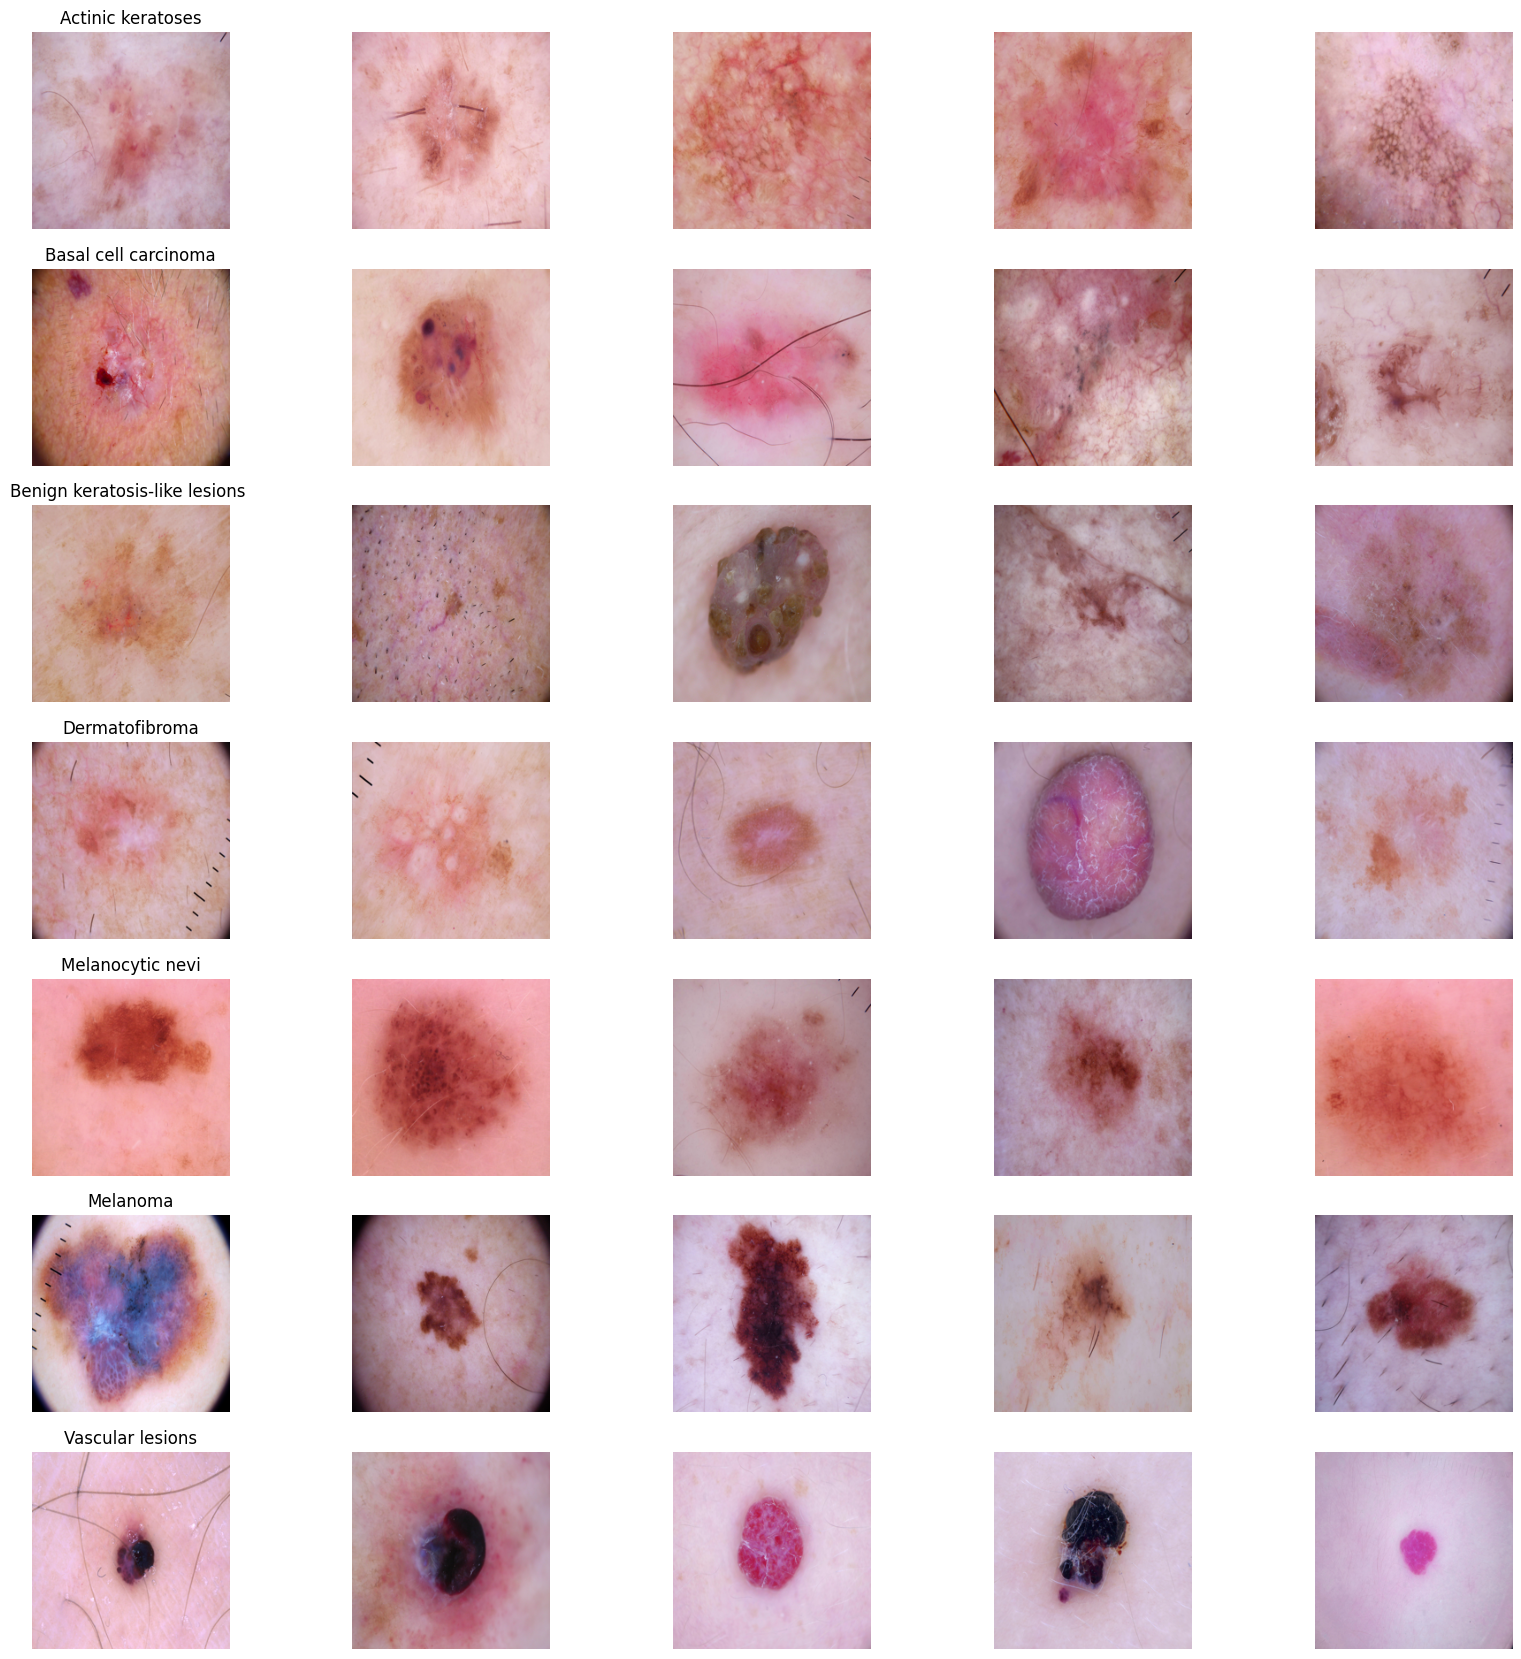

In [13]:
n_samples = 5
fig, m_axs = plt.subplots(7, n_samples, figsize = (4*n_samples, 3*7))
for n_axs, (type_name, type_rows) in zip(m_axs, 
                                         df.sort_values(['cell_type']).groupby('cell_type')):
    n_axs[0].set_title(type_name)
    for c_ax, (_, c_row) in zip(n_axs, type_rows.sample(n_samples, random_state=2018).iterrows()):
        c_ax.imshow(c_row['image'])
        c_ax.axis('off')
fig.savefig('category_samples.png', dpi=300)

In [16]:
df['image'].map(lambda x: x.shape).value_counts()

image
(224, 224, 3)    10015
Name: count, dtype: int64

<Axes: title={'center': 'CELL TYPE'}, xlabel='cell_type', ylabel='Count'>

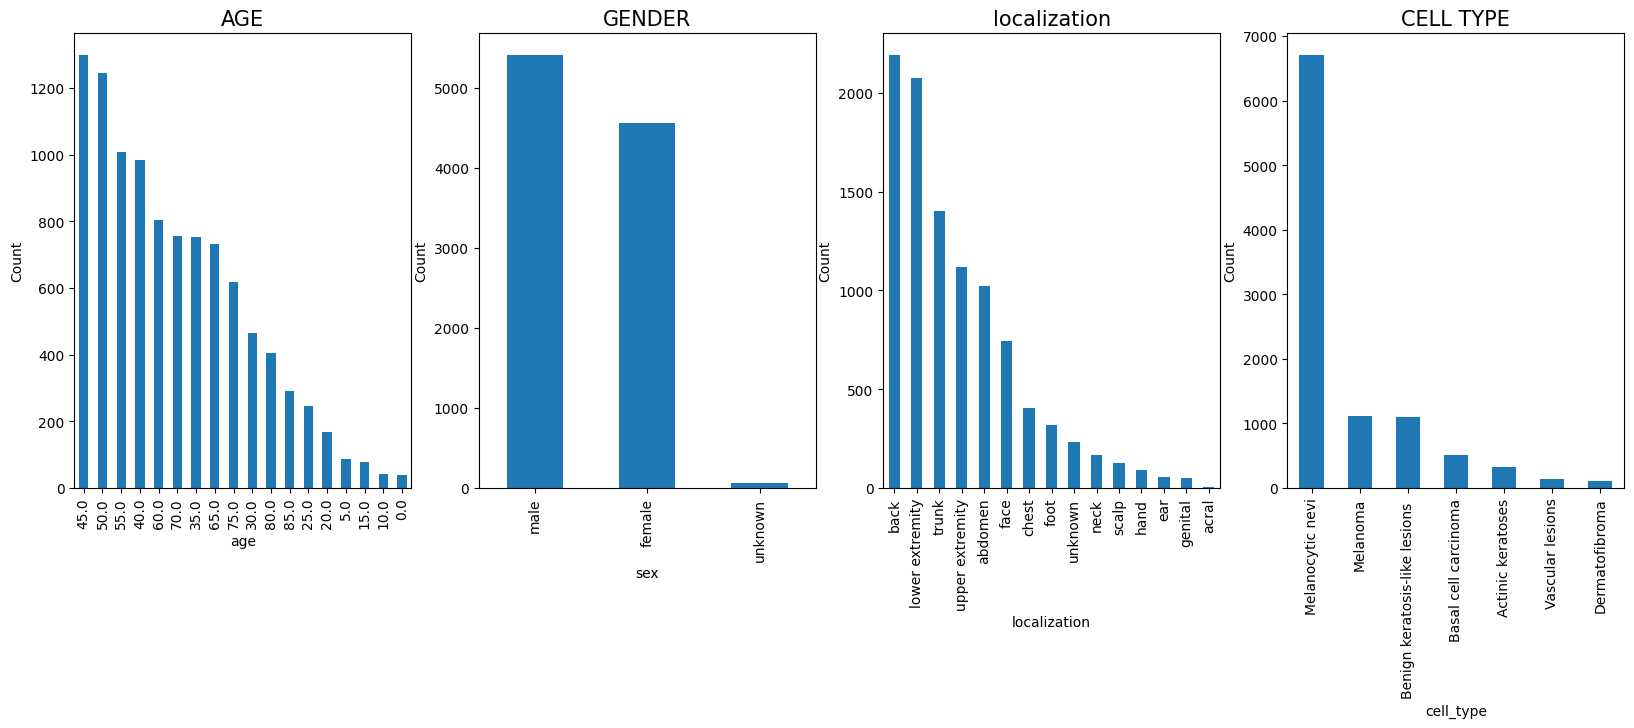

In [15]:
plt.figure(figsize=(20,10))
plt.subplots_adjust(left=0.125, bottom=1, right=0.9, top=2, hspace=0.2)
plt.subplot(2,4,1)
plt.title("AGE",fontsize=15)
plt.ylabel("Count")
df['age'].value_counts().plot.bar()

plt.subplot(2,4,2)
plt.title("GENDER",fontsize=15)
plt.ylabel("Count")
df['sex'].value_counts().plot.bar()

plt.subplot(2,4,3)
plt.title("localization",fontsize=15)
plt.ylabel("Count")
plt.xticks(rotation=45)
df['localization'].value_counts().plot.bar()

plt.subplot(2,4,4)
plt.title("CELL TYPE",fontsize=15)
plt.ylabel("Count")
df['cell_type'].value_counts().plot.bar()

Skin diseases are found to be maximum in people aged around 45. Minimum for 10 and below. We also observe that the probability of having skin disease increases with the increase in age.
Skin diseases are more prominent in Men as compared to Women and other gender.
Skin diseases are more visible on the "back" of the body and least on the "acral surfaces"(such as limbs, fingers, or ears).
The most found disease among people is Melanocytic nevi while the least found is Dermatofibroma.

<Axes: title={'center': 'LOCALIZATION VS GENDER'}, xlabel='count', ylabel='localization'>

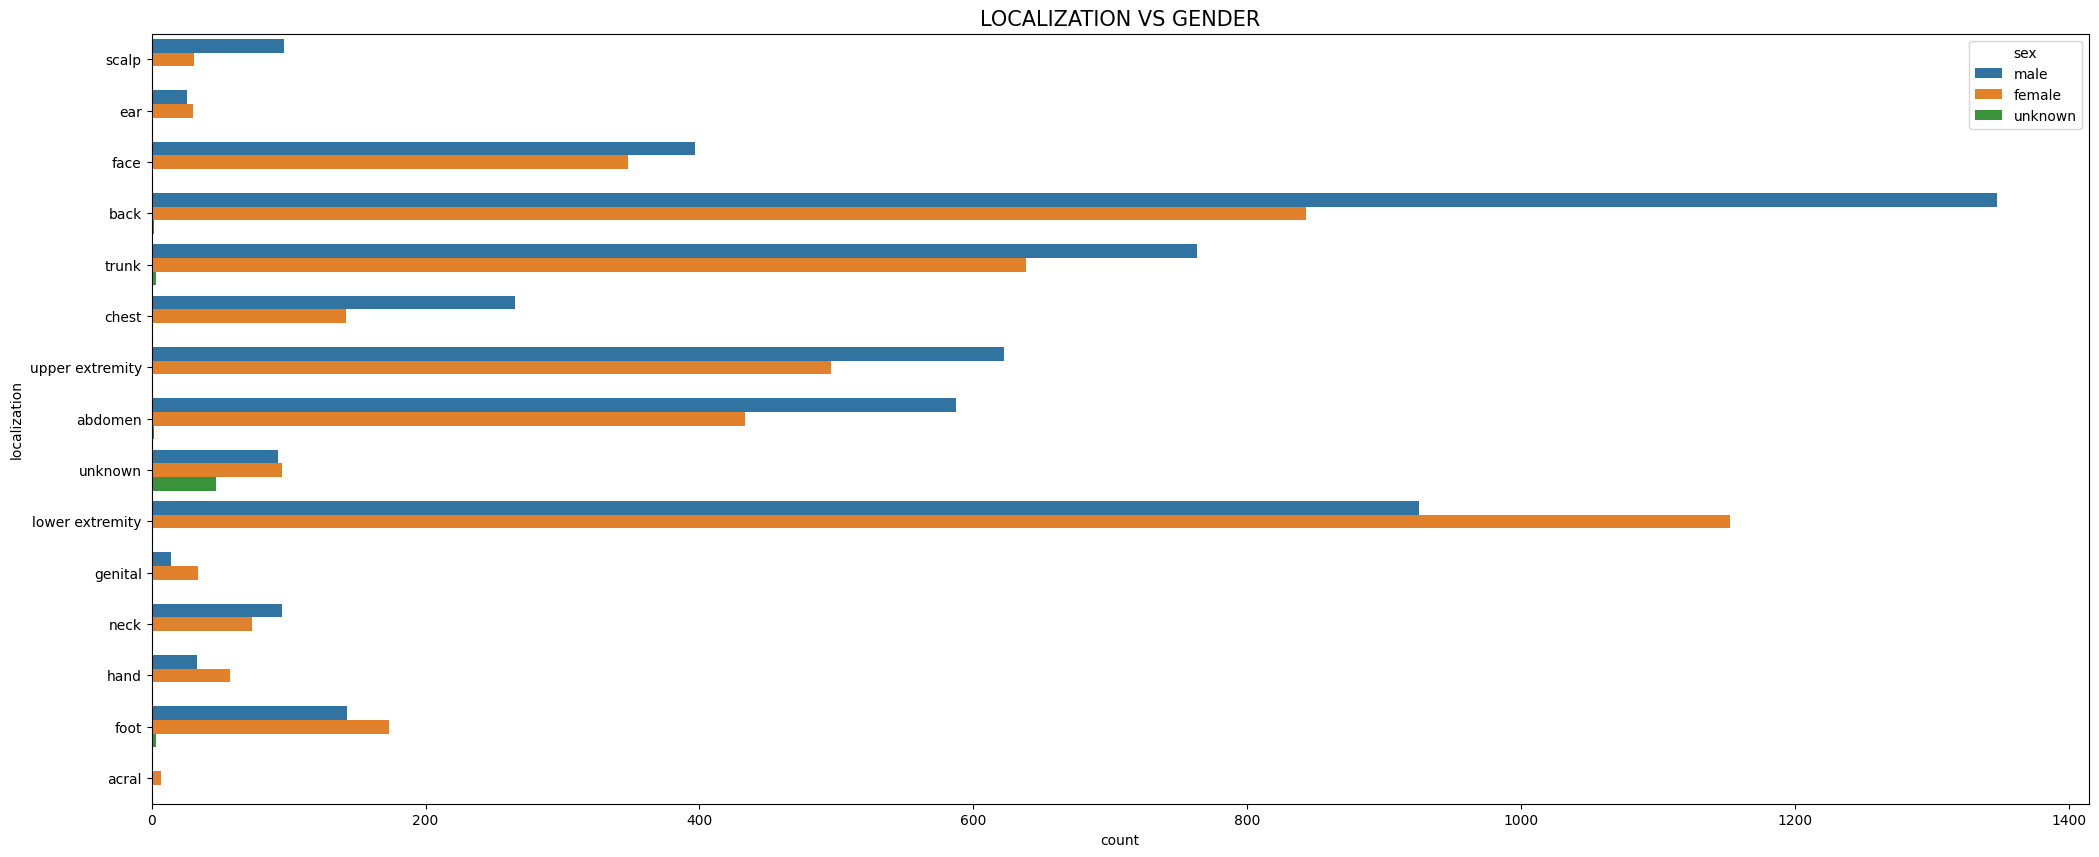

In [16]:
plt.figure(figsize=(25,10))
plt.title('LOCALIZATION VS GENDER',fontsize = 15)
sns.countplot(y='localization', hue='sex',data=df)

<Axes: title={'center': 'LOCALIZATION VS CELL TYPE'}, xlabel='count', ylabel='localization'>

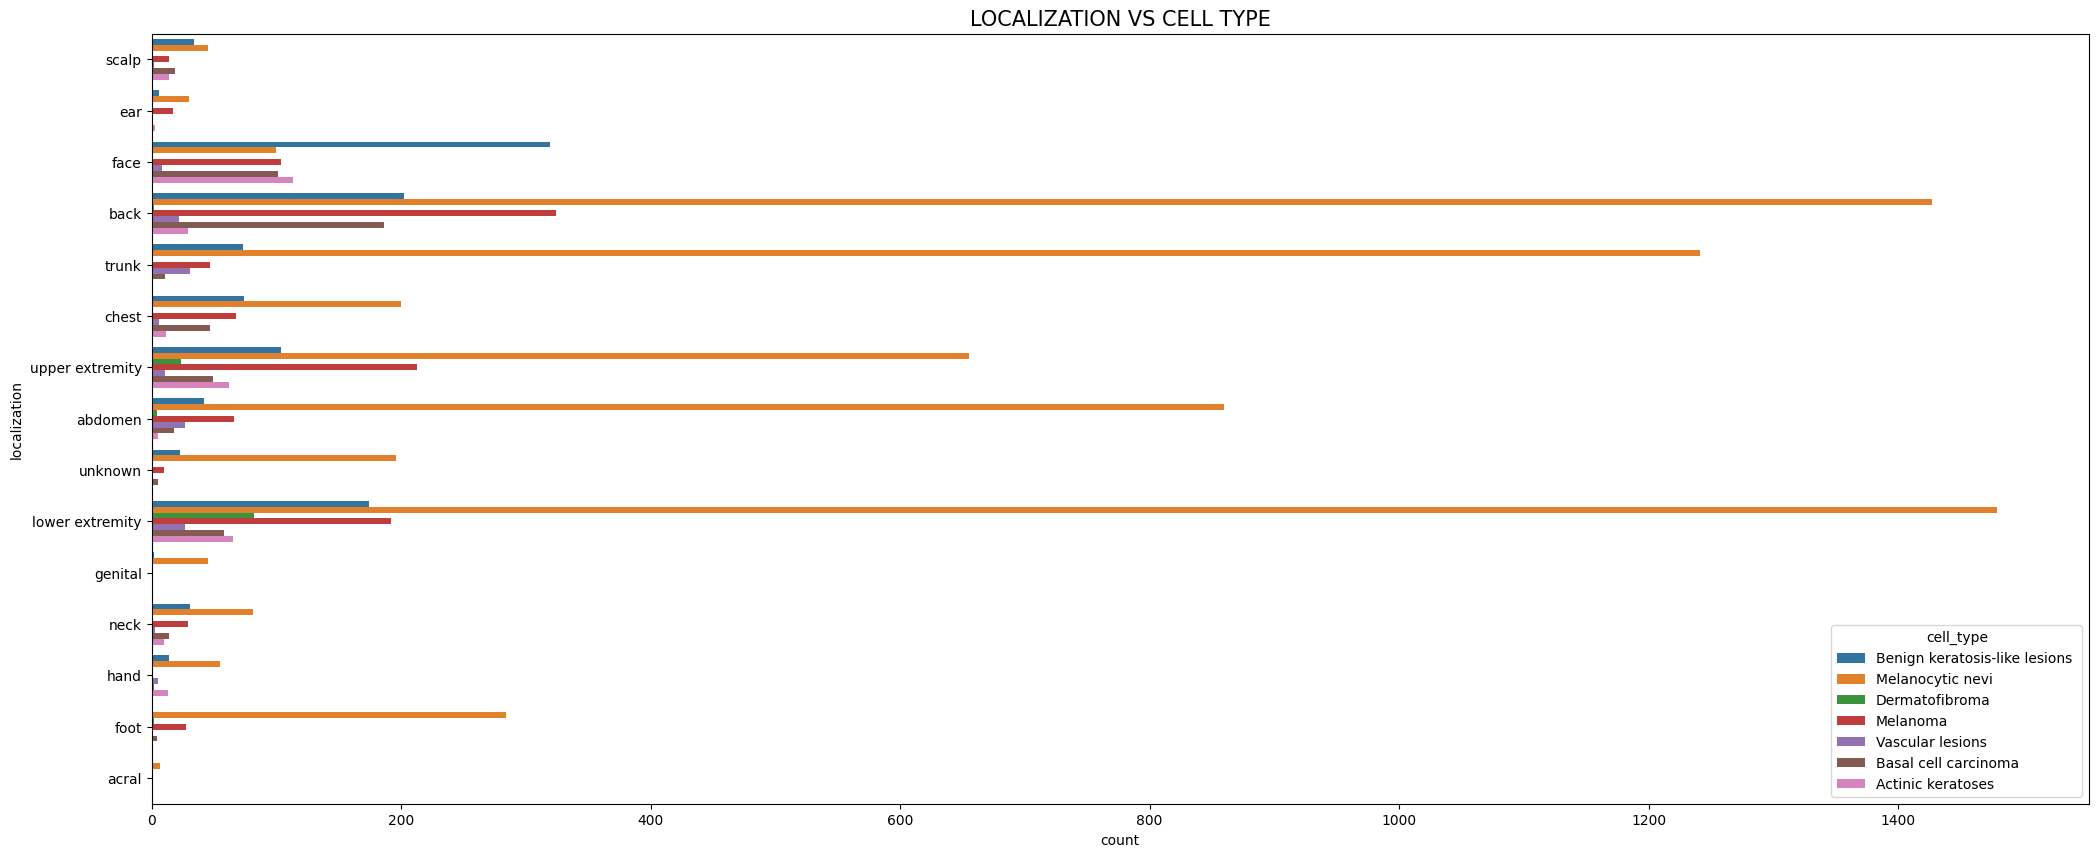

In [17]:
plt.figure(figsize=(25,10))
plt.title('LOCALIZATION VS CELL TYPE',fontsize = 15)
sns.countplot(y='localization', hue='cell_type',data=df)

Back are is the most affected among people and more prominent in men.
Infection on Lower extremity of the body is more visible in women.
Some unknown regions also show infections and it's visible in men, women and other genders.
The acral surfaces show the least infection cases that too in men only. Other gender groups don't show this kind of infection.

<Axes: title={'center': 'GENDER VS CELL TYPE'}, xlabel='count', ylabel='sex'>

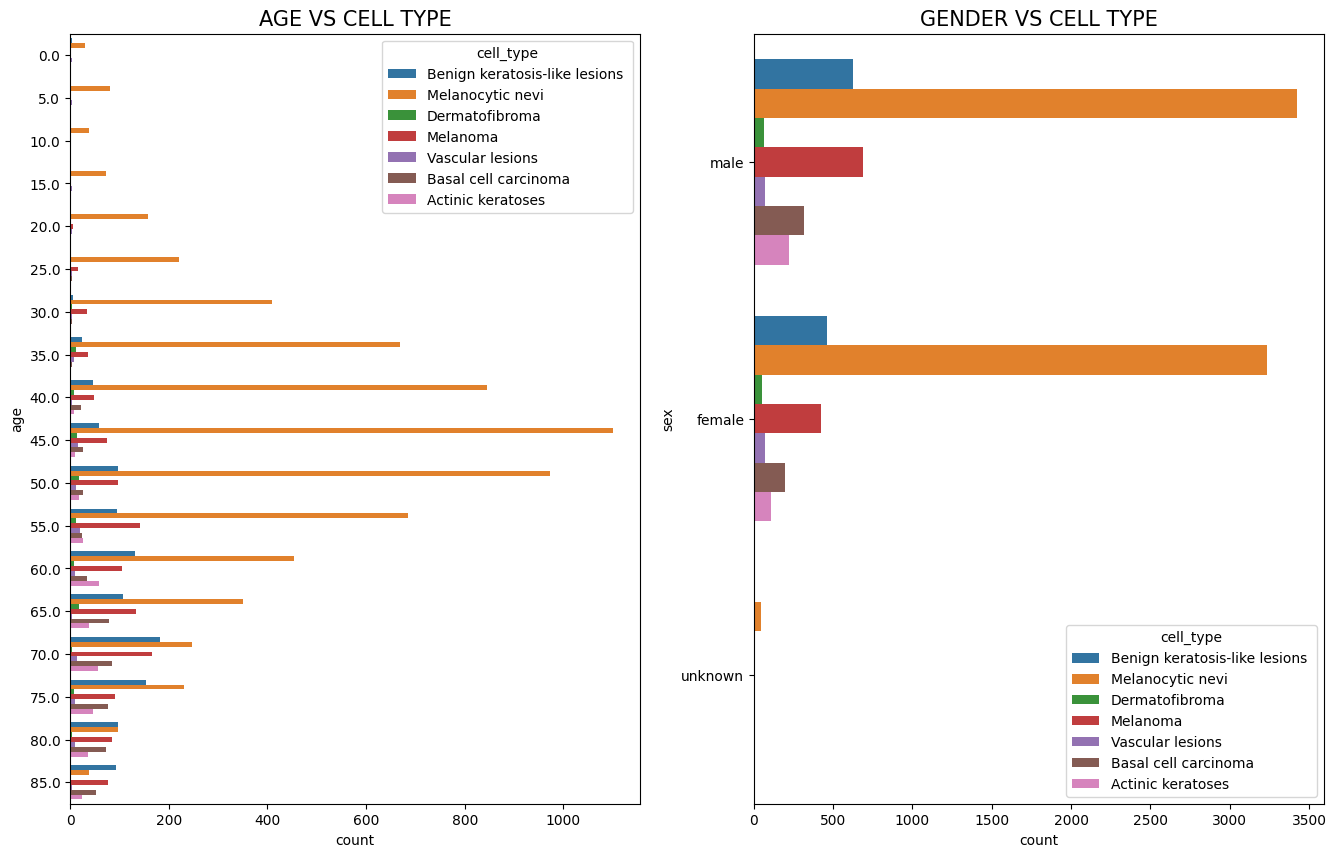

In [18]:
plt.figure(figsize=(25,10))
plt.subplot(131)
plt.title('AGE VS CELL TYPE',fontsize = 15)
sns.countplot(y='age', hue='cell_type',data=df)
plt.subplot(132)
plt.title('GENDER VS CELL TYPE',fontsize = 15)
sns.countplot(y='sex', hue='cell_type',data=df)

The age group between 0-75 years is infected the most by Melanocytic nevi. On the other hand, the people aged 80-90 are affected more by Benign keratosis-like lesions.

All the gender groups are affected the most by Melanocytic nevi.

In [17]:
features=df.drop(columns=['cell_type_idx'],axis=1)
target=df['cell_type_idx']

In [18]:
features.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,path,cell_type,image
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,../input/skin-cancer-mnist-ham10000/ham10000_i...,Benign keratosis-like lesions,"[[[187, 150, 192], [190, 154, 195], [192, 156,..."
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,../input/skin-cancer-mnist-ham10000/ham10000_i...,Benign keratosis-like lesions,"[[[24, 13, 22], [25, 13, 23], [24, 14, 23], [2..."
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,../input/skin-cancer-mnist-ham10000/ham10000_i...,Benign keratosis-like lesions,"[[[186, 127, 135], [188, 129, 137], [191, 135,..."
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,../input/skin-cancer-mnist-ham10000/ham10000_i...,Benign keratosis-like lesions,"[[[23, 11, 15], [24, 11, 18], [24, 10, 19], [2..."
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,../input/skin-cancer-mnist-ham10000/ham10000_i...,Benign keratosis-like lesions,"[[[125, 83, 105], [132, 89, 112], [138, 93, 11..."


In [19]:
from sklearn.model_selection import train_test_split
import tensorflow as tf

x_train_o, x_test_o, y_train_o, y_test_o = train_test_split(features, target, test_size=0.25,random_state=666)
tf.unique(x_train_o.cell_type.values)

Unique(y=<tf.Tensor: shape=(7,), dtype=string, numpy=
array([b'Melanocytic nevi', b'Basal cell carcinoma', b'Melanoma',
       b'Vascular lesions', b'Benign keratosis-like lesions ',
       b'Actinic keratoses', b'Dermatofibroma'], dtype=object)>, idx=<tf.Tensor: shape=(7511,), dtype=int32, numpy=array([0, 1, 0, ..., 1, 0, 0], dtype=int32)>)

In [20]:
x_train = np.asarray(x_train_o['image'].tolist())
x_test = np.asarray(x_test_o['image'].tolist())

x_train_mean = np.mean(x_train)
x_train_std = np.std(x_train)

x_test_mean = np.mean(x_test)
x_test_std = np.std(x_test)

x_train = (x_train - x_train_mean)/x_train_std
x_test = (x_test - x_test_mean)/x_test_std

In [21]:
# Perform one-hot encoding on the labels
y_train = to_categorical(y_train_o, num_classes = 7)
y_test = to_categorical(y_test_o, num_classes = 7)
y_test

array([[0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.]])

In [22]:
x_train, x_validate, y_train, y_validate = train_test_split(x_train, y_train, test_size = 0.1, random_state = 999)
x_train = x_train.reshape(x_train.shape[0], *(224, 224, 3))
x_test = x_test.reshape(x_test.shape[0], *(224, 224, 3))
x_validate = x_validate.reshape(x_validate.shape[0], *(224, 224, 3))

In [23]:
# Flatten the training data
x_train_flat = x_train.reshape(x_train.shape[0], -1)

# Flatten the validation data
x_validate_flat = x_validate.reshape(x_validate.shape[0], -1)

# Flatten the test data
x_test_flat = x_test.reshape(x_test.shape[0], -1)


In [26]:
# from sklearn.preprocessing import StandardScaler
# # Initialize the scaler
# scaler = StandardScaler()

# # Fit and transform the scaler on the training data
# X_train_scaled = scaler.fit_transform(x_train_flat)

# # Transform the validation and test data using the same scaler
# X_validate_scaled = scaler.transform(x_validate_flat)
# X_test_scaled = scaler.transform(x_test_flat)


In [27]:
# from tensorflow.keras.applications import MobileNet
# from tensorflow.keras.models import Model
# from sklearn.preprocessing import StandardScaler
# from sklearn.model_selection import train_test_split
# from xgboost import XGBClassifier
# import xgboost as xgb
# import numpy as np

# # Load the pre-trained MobileNet model without the top layer
# base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# # Create a model that outputs the features from MobileNet
# model = Model(inputs=base_model.input, outputs=base_model.layers[-1].output)

# # Extract features from the training dataset using MobileNet
# features_train = model.predict(x_train)
# features_train = features_train.reshape(features_train.shape[0], -1)  # Flatten to a 2D array for XGBoost

# # Normalize features using StandardScaler
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(features_train)

# # Split the dataset into training and validation sets
# x_train, x_validate, y_train, y_validate = train_test_split(X_train_scaled, y_train, test_size=0.1, random_state=999)

# # Extract features from the test dataset using MobileNet
# features_test = model.predict(x_test)
# features_test = features_test.reshape(features_test.shape[0], -1)  # Flatten to a 2D array
# X_test_scaled = scaler.transform(features_test)

# # Parameters for XGBoost
# params = {
#     'objective': 'multi:softmax',
#     'num_class': len(set(y_train)),  # Number of classes in your dataset
#     'learning_rate': 0.1,
#     'max_depth': 6,
#     'eval_metric': 'mlogloss'
# }

# # Initialize a DMatrix for the test data (for evaluation purposes)
# dtest = xgb.DMatrix(X_test_scaled, label=y_test)

# # Set up the batch size
# batch_size = 2  # Adjust the batch size based on your available memory

# # Initialize the booster to None for the first iteration
# booster = None

# # Loop over the training data in batches
# for start in range(0, x_train.shape[0], batch_size):
#     end = min(start + batch_size, x_train.shape[0])
#     print(f"Training on batch from {start} to {end}...")

#     # Create a DMatrix for the current batch
#     dtrain = xgb.DMatrix(x_train[start:end], label=y_train[start:end])

#     # Train the model on the current batch
#     booster = xgb.train(
#         params,
#         dtrain,
#         num_boost_round=10,  # Number of boosting rounds for each batch
#         xgb_model=booster,  # Pass the previous booster to continue training
#         evals=[(dtest, 'test')],
#         verbose_eval=True
#     )

# # Save the final model
# booster.save_model('xgboost_final_model.json')

# # Make predictions on the test set
# predictions = booster.predict(dtest)

# # Evaluate the accuracy of the predictions
# accuracy = np.mean(predictions == y_test)
# print(f"XGBoost Classification accuracy: {accuracy * 100:.2f}%")


In [28]:
# from tensorflow.keras.applications import MobileNet
# from tensorflow.keras.models import Model
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.preprocessing import StandardScaler
# from sklearn.model_selection import train_test_split
# import numpy as np

# # Load the pre-trained MobileNet model without the top layer
# base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# # Create a model that outputs the features from MobileNet
# model = Model(inputs=base_model.input, outputs=base_model.layers[-1].output)

# # Extract features from your training dataset using MobileNet
# features_train = model.predict(x_train)  # Feature extraction using MobileNet
# features_train = features_train.reshape(features_train.shape[0], -1)  # Flatten to a 2D array for classification

# # Extract features from your test dataset using MobileNet
# features_test = model.predict(x_test)  # Feature extraction for test data
# features_test = features_test.reshape(features_test.shape[0], -1)  # Flatten for scaling

# # Normalize features using StandardScaler
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(features_train)
# X_test_scaled = scaler.transform(features_test)  # Use features_test here

# # Initialize the Random Forest model
# class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
# rf_model = RandomForestClassifier(n_estimators=50,  # Reduce number of trees if necessary
#                                    class_weight={i: w for i, w in enumerate(class_weights)},
#                                    random_state=42,
#                                    n_jobs=-1)  # Use all available cores
# # rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# # Fit the model on the training data
# rf_model.fit(X_train_scaled, y_train)

# # Make predictions on the test set
# predictions = rf_model.predict(X_test_scaled)

# # Evaluate accuracy
# accuracy = np.mean(predictions == y_test)
# print(f"Random Forest Classification accuracy: {accuracy * 100:.2f}%")


In [29]:
# # Confusion matrix
# conf_matrix = confusion_matrix(y_test.argmax(axis=1), predictions.argmax(axis=1))  # Use argmax to convert multilabel to single label
# print("Confusion Matrix:")
# print(conf_matrix)

# # Precision and Recall
# precision = precision_score(y_test, predictions, average='micro')  # Use 'micro', 'macro', or 'samples' as appropriate
# recall = recall_score(y_test, predictions, average='micro')

# print(f"Precision: {precision:.2f}")
# print(f"Recall: {recall:.2f}")

# **Snapshot**

In [20]:
# Snapshot
from tensorflow.keras.utils import to_categorical

# Check if labels are already one-hot encoded
if y_train.ndim == 2:
    print("Labels are already one-hot encoded.")
elif y_train.ndim == 3:
    print(f"Fixing label shape: {y_train.shape}")
    y_train = y_train.reshape(y_train.shape[0], -1)  # Flatten the extra dimension
    y_test = y_test.reshape(y_test.shape[0], -1)
else:
    print("Converting labels to one-hot encoding.")
    y_train = to_categorical(y_train, num_classes=7)
    y_test = to_categorical(y_test, num_classes=7)

# Verify shapes
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


y_train = to_categorical(y_train, num_classes=7)
y_test = to_categorical(y_test, num_classes=7)

# Verify shapes
print(f"y_train shape: {y_train.shape}")  # Should be (6759, 7)
print(f"y_test shape: {y_test.shape}")    # Should be (2504, 7)


if y_train.ndim == 3:
    y_train = y_train[:, 0, :]  # Keep only the first row if all rows are identical
    y_test = y_test[:, 0, :]

print(f"Fixed y_train shape: {y_train.shape}")  # Should be (6759, 7)
print(f"Fixed y_test shape: {y_test.shape}")    # Should be (2504, 7)

Labels are already one-hot encoded.
y_train shape: (6759, 7)
y_test shape: (2504, 7)
y_train shape: (6759, 7, 7)
y_test shape: (2504, 7, 7)
Fixed y_train shape: (6759, 7)
Fixed y_test shape: (2504, 7)


In [24]:
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import LearningRateScheduler, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
from keras_tuner import Hyperband
from sklearn.preprocessing import StandardScaler
import numpy as np

# Load the pre-trained MobileNet model without the top layer
base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Create a model that outputs the features from MobileNet
feature_extractor = Model(inputs=base_model.input, outputs=base_model.layers[-1].output)

# Extract features from the training dataset using MobileNet
features_train = feature_extractor.predict(x_train, batch_size=16)
features_train = features_train.reshape(features_train.shape[0], -1)  # Flatten to a 2D array

# Extract features from the test dataset using MobileNet
features_test = feature_extractor.predict(x_test, batch_size=16)
features_test = features_test.reshape(features_test.shape[0], -1)  # Flatten to a 2D array

# Normalize features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(features_train)
X_test_scaled = scaler.transform(features_test)

# Convert labels to categorical
y_train = to_categorical(y_train, num_classes=7)  # Adjust for the number of classes
y_test = to_categorical(y_test, num_classes=7)

if y_train.ndim == 3:
    y_train = y_train[:, 0, :]  # Keep only the first row if all rows are identical
    y_test = y_test[:, 0, :]

print(f"Fixed y_train shape: {y_train.shape}")  # Should be (6759, 7)
print(f"Fixed y_test shape: {y_test.shape}")    # Should be (2504, 7)


num_classes = 7  # Replace 7 with the actual number of classes in your dataset

def build_model(hp):
    model = Sequential()
    model.add(Dense(
        units=hp.Int("units_1", min_value=128, max_value=512, step=64),
        activation=hp.Choice("activation_1", values=["relu", "tanh"]),
        input_dim=X_train_scaled.shape[1]
    ))
    model.add(Dropout(hp.Float("dropout_1", min_value=0.3, max_value=0.7, step=0.1)))
    model.add(Dense(
        units=hp.Int("units_2", min_value=128, max_value=512, step=64),
        activation=hp.Choice("activation_2", values=["relu", "tanh"])
    ))
    model.add(Dropout(hp.Float("dropout_2", min_value=0.3, max_value=0.7, step=0.1)))
    model.add(Dense(num_classes, activation="softmax"))  # Ensure consistent output shape
    model.compile(
        optimizer=hp.Choice("optimizer", values=["adam", "sgd"]),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


# Initialize KerasTuner Hyperband tuner
tuner = Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=20,
    directory='hyperparameter_tuning',
    project_name='mobilenet_classifier'
)

# Learning rate schedule for snapshot ensemble
def cosine_annealing(epoch, lr_max=0.1, T=10):
    return lr_max * (1 + np.cos(np.pi * (epoch % T) / T)) / 2

# Callback for snapshot ensemble
callbacks = [
    LearningRateScheduler(cosine_annealing)
]

# Perform the search for best hyperparameters
tuner.search(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=10,
    batch_size=16,
    callbacks=callbacks
)

# Retrieve the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

# Build and train the best model
model = tuner.hypermodel.build(best_hps)

# Add checkpoint for snapshot ensemble
snapshot_callbacks = callbacks + [
    ModelCheckpoint(
        filepath='snapshot_weights_epoch_{epoch}.weights.h5',
        save_best_only=False,
        save_weights_only=True
    )
]

# Train the model with snapshot ensemble
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=50,
    batch_size=16,
    callbacks=snapshot_callbacks
)

# Aggregate predictions from snapshots
snapshots = [f'snapshot_weights_epoch_{i}.weights.h5' for i in range(10, 51, 10)]
snapshot_predictions = []

for snapshot in snapshots:
    model.load_weights(snapshot)
    snapshot_predictions.append(model.predict(X_test_scaled))

# Average predictions from snapshots
ensemble_predictions = np.mean(snapshot_predictions, axis=0)
final_predictions = np.argmax(ensemble_predictions, axis=1)

# Evaluate accuracy
ensemble_accuracy = np.mean(final_predictions == np.argmax(y_test, axis=1))
print(f"Snapshot Ensemble Classification accuracy: {ensemble_accuracy * 100:.2f}%")


Trial 26 Complete [00h 00m 51s]
val_accuracy: 0.9780351519584656

Best val_accuracy So Far: 0.9780351519584656
Total elapsed time: 00h 35m 11s
Epoch 1/50
423/423 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.8865 - loss: 0.3839 - val_accuracy: 0.9740 - val_loss: 0.0994 - learning_rate: 0.0100
Epoch 2/50
423/423 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9741 - loss: 0.0785 - val_accuracy: 0.9752 - val_loss: 0.1112 - learning_rate: 0.0098
Epoch 3/50
423/423 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9774 - loss: 0.0638 - val_accuracy: 0.9756 - val_loss: 0.1001 - learning_rate: 0.0088
Epoch 4/50
423/423 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9835 - loss: 0.0479 - val_accuracy: 0.9756 - val_loss: 0.1068 - learning_rate: 0.0070
Epoch 5/50
423/423 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9870 - loss: 0.0350 - val_accuracy: 0.9764 - val_loss: 0.1107 - learning_rate: 0.0046
Epoch 6/50
423/423 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9920 - loss: 0.0235 - val_accu

Metrics for Trial ID 0025:
Val Loss History: [MetricObservation(value=[0.10110099613666534], step=3)]
Val Accuracy History: [MetricObservation(value=[0.9780351519584656], step=3)]
Loss History: [MetricObservation(value=[0.03914080932736397], step=3)]
Accuracy History: [MetricObservation(value=[0.98653644323349], step=3)]
Final Val Loss: [0.10110099613666534]
Final Val Accuracy: [0.9780351519584656]
Final Loss: [0.03914080932736397]
Final Accuracy: [0.98653644323349]
Metrics for Trial ID 0013:
Val Loss History: [MetricObservation(value=[0.10160081833600998], step=3)]
Val Accuracy History: [MetricObservation(value=[0.9768370389938354], step=3)]
Loss History: [MetricObservation(value=[0.031484752893447876], step=3)]
Accuracy History: [MetricObservation(value=[0.9894955158233643], step=3)]
Final Val Loss: [0.10160081833600998]
Final Val Accuracy: [0.9768370389938354]
Final Loss: [0.031484752893447876]
Final Accuracy: [0.9894955158233643]
Metrics for Trial ID 0024:
Val Loss History: [Metric

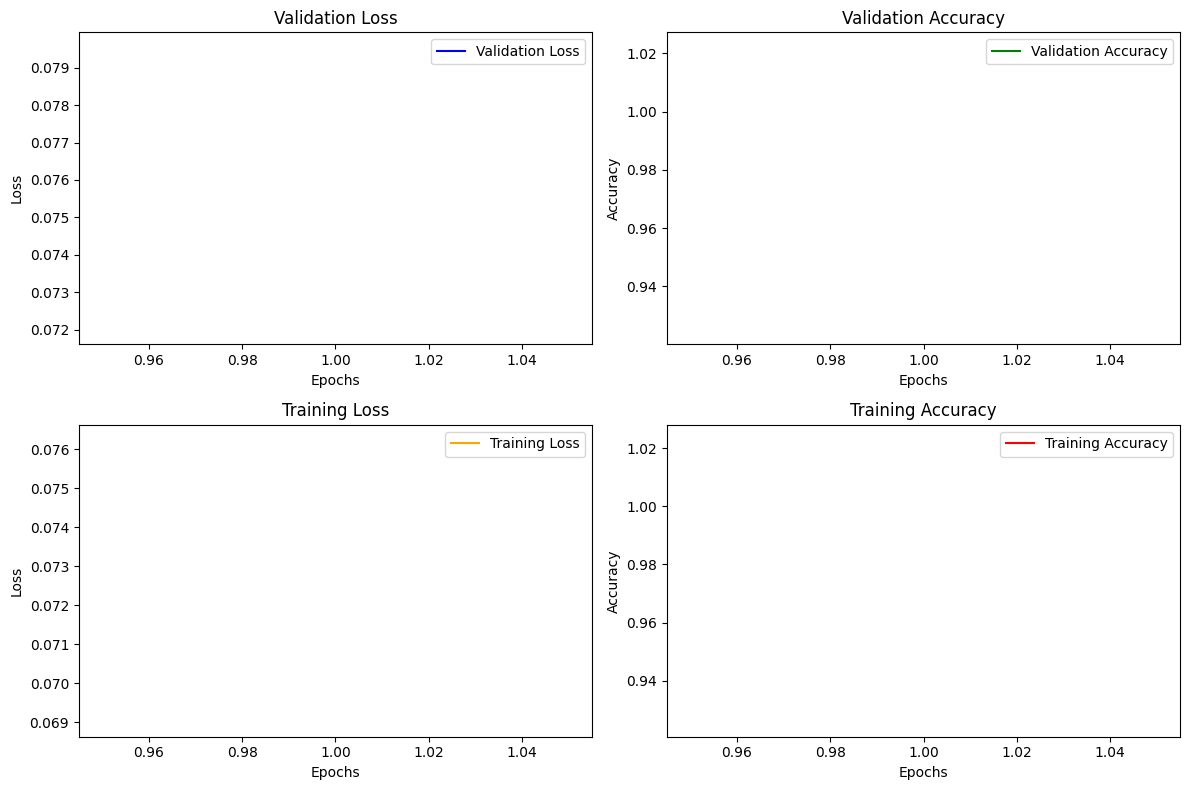

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# Retrieve all trials from the tuner
trials = tuner.oracle.get_best_trials(num_trials=len(tuner.oracle.trials))

# Extract hyperparameters and metrics
data = []
for trial in trials:
    # Get hyperparameters for this trial
    hp_values = trial.hyperparameters.values
    
    # Debugging: Check if metrics are available
    try:
        # Check if metrics are tracked for this trial
        print(f"Metrics for Trial ID {trial.trial_id}:")
        print(f"Val Loss History: {trial.metrics.get_history('val_loss')}")
        print(f"Val Accuracy History: {trial.metrics.get_history('val_accuracy')}")
        print(f"Loss History: {trial.metrics.get_history('loss')}")
        print(f"Accuracy History: {trial.metrics.get_history('accuracy')}")
        
        # Retrieve metric history (extracting the numerical values from MetricObservation objects)
        val_loss_history = [metric.value for metric in trial.metrics.get_history("val_loss")]
        val_accuracy_history = [metric.value for metric in trial.metrics.get_history("val_accuracy")]
        loss_history = [metric.value for metric in trial.metrics.get_history("loss")]
        accuracy_history = [metric.value for metric in trial.metrics.get_history("accuracy")]
        
        # Debugging: Check if the metric histories have data
        print(f"Final Val Loss: {val_loss_history[-1] if val_loss_history else 'N/A'}")
        print(f"Final Val Accuracy: {val_accuracy_history[-1] if val_accuracy_history else 'N/A'}")
        print(f"Final Loss: {loss_history[-1] if loss_history else 'N/A'}")
        print(f"Final Accuracy: {accuracy_history[-1] if accuracy_history else 'N/A'}")
        
        # If the histories are available, append the data
        if val_loss_history and val_accuracy_history and loss_history and accuracy_history:
            final_metrics = {
                "val_loss": val_loss_history[-1],
                "val_accuracy": val_accuracy_history[-1],
                "loss": loss_history[-1],
                "accuracy": accuracy_history[-1]
            }
            entry = {**hp_values, **final_metrics}
            data.append(entry)
    except ValueError as e:
        print(f"Error retrieving metrics for Trial ID {trial.trial_id}: {e}")

# Convert to a DataFrame
df = pd.DataFrame(data)

# Display the table
print("Hyperparameter and Metrics Table:")
print(df)

# Save the table to a CSV (optional)
df.to_csv("hyperparameter_metrics.csv", index=False)

# Identify the best trial based on validation loss (minimizing the val_loss)
best_trial_index = df["val_loss"].idxmin()
best_trial = df.loc[best_trial_index]
print("\nBest Trial Hyperparameters and Metrics:")
print(best_trial)

# Plot metrics for the best trial
val_loss_history = [metric.value for metric in trials[best_trial_index].metrics.get_history("val_loss")]
val_accuracy_history = [metric.value for metric in trials[best_trial_index].metrics.get_history("val_accuracy")]
loss_history = [metric.value for metric in trials[best_trial_index].metrics.get_history("loss")]
accuracy_history = [metric.value for metric in trials[best_trial_index].metrics.get_history("accuracy")]

# Prepare the data for plotting
epochs = range(1, len(val_loss_history) + 1)

plt.figure(figsize=(12, 8))

# Plot Validation Loss
plt.subplot(2, 2, 1)
plt.plot(epochs, val_loss_history, label="Validation Loss", color="blue")
plt.title("Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# Plot Validation Accuracy
plt.subplot(2, 2, 2)
plt.plot(epochs, val_accuracy_history, label="Validation Accuracy", color="green")
plt.title("Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Plot Training Loss
plt.subplot(2, 2, 3)
plt.plot(epochs, loss_history, label="Training Loss", color="orange")
plt.title("Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# Plot Training Accuracy
plt.subplot(2, 2, 4)
plt.plot(epochs, accuracy_history, label="Training Accuracy", color="red")
plt.title("Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import LearningRateScheduler, ModelCheckpoint
from sklearn.preprocessing import StandardScaler
import numpy as np
import tensorflow as tf

# Rebuild the model with the best hyperparameters
def build_model():
    model = Sequential()
    model.add(Dense(512, activation="relu", input_dim=X_train_scaled.shape[1]))
    model.add(Dropout(0.6))
    model.add(Dense(128, activation="tanh"))
    model.add(Dropout(0.3))
    model.add(Dense(7, activation="softmax"))  # Adjust for 7 classes
    model.compile(
        optimizer="sgd", 
        loss="categorical_crossentropy", 
        metrics=["accuracy"]
    )
    return model

# Learning rate scheduler (cosine annealing)
def cosine_annealing(epoch, lr_max=0.1, T=10):
    return lr_max * (1 + np.cos(np.pi * (epoch % T) / T)) / 2

# Callbacks for learning rate scheduler and saving snapshots
callbacks = [
    LearningRateScheduler(cosine_annealing),
    ModelCheckpoint(
        filepath='snapshot_weights_epoch_{epoch}.weights.h5',
        save_best_only=False,
        save_weights_only=True
    )
]

# Rebuild the model
model = build_model()

# Train the model with snapshot ensemble
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=50,
    batch_size=16,
    callbacks=callbacks
)

# Collect predictions from different snapshot models
snapshots = [f'snapshot_weights_epoch_{i}.weights.h5' for i in range(10, 51, 10)]
snapshot_predictions = []

# Load the saved snapshot weights and make predictions
for snapshot in snapshots:
    model.load_weights(snapshot)
    snapshot_predictions.append(model.predict(X_test_scaled))

# Average the predictions from different snapshots
ensemble_predictions = np.mean(snapshot_predictions, axis=0)

# Get the final predictions by choosing the class with the highest probability
final_predictions = np.argmax(ensemble_predictions, axis=1)

# Evaluate the accuracy of the snapshot ensemble
ensemble_accuracy = np.mean(final_predictions == np.argmax(y_test, axis=1))
print(f"Snapshot Ensemble Classification accuracy: {ensemble_accuracy * 100:.2f}%")


/opt/conda/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
423/423 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.9088 - loss: 0.3395 - val_accuracy: 0.9736 - val_loss: 0.1006 - learning_rate: 0.0100
Epoch 2/50
423/423 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9716 - loss: 0.0892 - val_accuracy: 0.9728 - val_loss: 0.0897 - learning_rate: 0.0098
Epoch 3/50
423/423 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9813 - loss: 0.0546 - val_accuracy: 0.9760 - val_loss: 0.0977 - learning_rate: 0.0088
Epoch 4/50
423/423 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9852 - loss: 0.0431 - val_accuracy: 0.9764 - val_loss: 0.0962 - learning_rate: 0.0070
Epoch 5/50
423/423 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9873 - loss: 0.0327 - val_accuracy: 0.9764 - val_loss: 0.1060 - learning_rate: 0.0046
Epoch 6/50
423/423 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9932 - loss: 0.0229 - val_accuracy: 0.9760 - val_loss: 0.1084 - learning_rate: 0.0023
Epoch 7/50
423/423 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9941 - loss: 0.0188 -

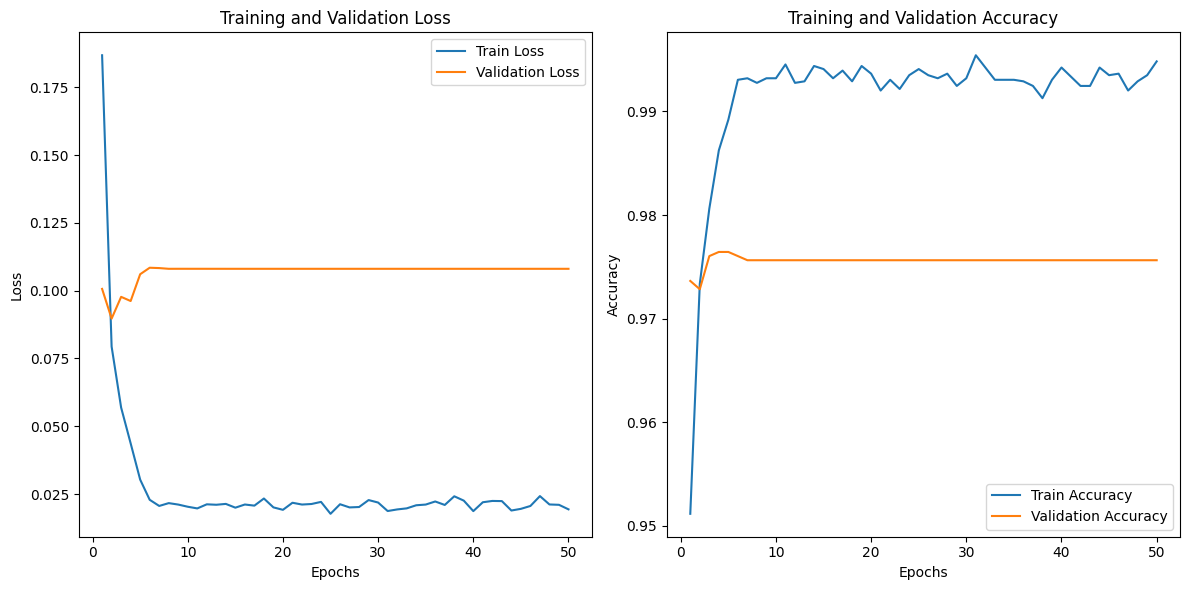

In [34]:
import matplotlib.pyplot as plt

# Extract metrics from history
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

# Plot Training and Validation Loss
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_loss) + 1), train_loss, label="Train Loss")
plt.plot(range(1, len(val_loss) + 1), val_loss, label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# Plot Training and Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_accuracy) + 1), train_accuracy, label="Train Accuracy")
plt.plot(range(1, len(val_accuracy) + 1), val_accuracy, label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


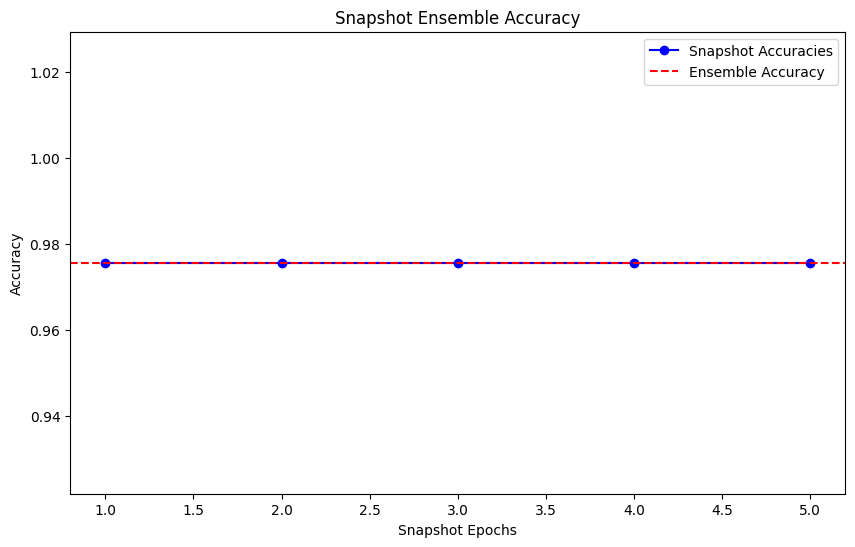

In [35]:
import matplotlib.pyplot as plt

# Store the accuracies of individual snapshots and ensemble
snapshot_accuracies = []
ensemble_accuracies = []

# For each snapshot, evaluate accuracy on the test set and store it
for snapshot in snapshots:
    model.load_weights(snapshot)
    snapshot_predictions = model.predict(X_test_scaled)
    snapshot_accuracy = np.mean(np.argmax(snapshot_predictions, axis=1) == np.argmax(y_test, axis=1))
    snapshot_accuracies.append(snapshot_accuracy)

# Plot snapshot accuracies
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(snapshot_accuracies) + 1), snapshot_accuracies, label="Snapshot Accuracies", marker='o', color='b')

# Plot ensemble accuracy
plt.axhline(ensemble_accuracy, label="Ensemble Accuracy", color='r', linestyle='--')

plt.title("Snapshot Ensemble Accuracy")
plt.xlabel("Snapshot Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


# **Attention**

In [1]:
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Reshape, Dense, Multiply, Conv2D, Concatenate, Lambda, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
from tensorflow.keras.utils import to_categorical
import tensorflow.keras.backend as K
from glob import glob
import os
import pandas as pd
from PIL import Image

# Squeeze-and-Excitation (SE) Block
def se_block(input_tensor, ratio=16):
    channels = input_tensor.shape[-1]
    
    # Squeeze: Global Average Pooling
    x = GlobalAveragePooling2D()(input_tensor)
    x = Reshape((1, 1, channels))(x)
    
    # Excitation: Fully connected layer with a reduction ratio (like 16)
    x = Dense(channels // ratio, activation='relu')(x)
    x = Dense(channels, activation='sigmoid')(x)
    
    # Scale the input tensor by the output of the excitation
    x = Multiply()([input_tensor, x])
    
    return x

# Channel Attention (CA) Block
def channel_attention(input_tensor, ratio=8):
    channels = input_tensor.shape[-1]
    
    # Squeeze: Global Average Pooling
    avg_pool = GlobalAveragePooling2D()(input_tensor)
    avg_pool = Reshape((1, 1, channels))(avg_pool)
    
    # Excitation: Fully connected layer
    fc1 = Dense(channels // ratio, activation='relu')(avg_pool)
    fc2 = Dense(channels, activation='sigmoid')(fc1)
    
    # Rescale the channels
    channel_attention = Multiply()([input_tensor, fc2])
    
    return channel_attention

# Spatial Attention (SA) Block
def spatial_attention(input_tensor):
    # Generate average and max pooled features
    avg_pool = Lambda(lambda x: K.mean(x, axis=-1, keepdims=True))(input_tensor)
    max_pool = Lambda(lambda x: K.max(x, axis=-1, keepdims=True))(input_tensor)
    
    # Concatenate and apply convolution to get spatial attention map
    concat = Concatenate(axis=-1)([avg_pool, max_pool])
    x = Conv2D(1, (7, 7), padding='same', activation='sigmoid')(concat)
    
    # Apply spatial attention
    spatial_attention = Multiply()([input_tensor, x])
    
    return spatial_attention

# CBAM Block (Channel + Spatial)
def cbam_block(input_tensor):
    x = channel_attention(input_tensor)
    x = spatial_attention(x)
    return x

# Load and preprocess the dataset
df = pd.read_csv('../input/skin-cancer-mnist-ham10000/HAM10000_metadata.csv')

df['age'].fillna(int(df['age'].median()), inplace=True)

lesion_type_dict = {
    'nv': 'Melanocytic nevi',
    'mel': 'Melanoma',
    'bkl': 'Benign keratosis-like lesions ',
    'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}

base_skin_dir = '../input/skin-cancer-mnist-ham10000'
imageid_path_dict = {os.path.splitext(os.path.basename(x))[0]: x
                     for x in glob(os.path.join(base_skin_dir, '*', '*.jpg'))}

df['path'] = df['image_id'].map(imageid_path_dict.get)
df['cell_type'] = df['dx'].map(lesion_type_dict.get)
df['cell_type_idx'] = pd.Categorical(df['cell_type']).codes

df['image'] = df['path'].map(lambda x: np.asarray(Image.open(x).resize((224, 224))))

features = df.drop(columns=['cell_type_idx'], axis=1)
target = df['cell_type_idx']

x_train_o, x_test_o, y_train_o, y_test_o = train_test_split(features, target, test_size=0.25, random_state=666)

x_train = np.asarray(x_train_o['image'].tolist())
x_test = np.asarray(x_test_o['image'].tolist())

x_train_mean = np.mean(x_train)
x_train_std = np.std(x_train)

x_test_mean = np.mean(x_test)
x_test_std = np.std(x_test)

x_train = (x_train - x_train_mean) / x_train_std
x_test = (x_test - x_test_mean) / x_test_std

# Perform one-hot encoding on the labels
y_train = to_categorical(y_train_o, num_classes=7)
y_test = to_categorical(y_test_o, num_classes=7)

x_train, x_validate, y_train, y_validate = train_test_split(x_train, y_train, test_size=0.1, random_state=999)
x_train = x_train.reshape(x_train.shape[0], *(224, 224, 3))
x_test = x_test.reshape(x_test.shape[0], *(224, 224, 3))
x_validate = x_validate.reshape(x_validate.shape[0], *(224, 224, 3))

# Load the pre-trained MobileNet model without the top layer
base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Add SE or CBAM to the MobileNet model
x = base_model.output
x = cbam_block(x)  # Use cbam_block(x) to add CBAM or se_block(x) for SE

# Continue with other layers
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(7, activation='softmax')(x)

# Define the final model
final_model = Model(inputs=base_model.input, outputs=x)

# Compile the model
final_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
final_model.fit(x_train, y_train, validation_data=(x_validate, y_validate), epochs=50, batch_size=32)

# Evaluate the model
test_loss, test_acc = final_model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_acc * 100:.2f}%")


/tmp/ipykernel_30/3888908420.py:73: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(int(df['age'].median()), inplace=True)


17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50


I0000 00:00:1733076357.162503      94 service.cc:145] XLA service 0x7ae71c004eb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1733076357.163136      94 service.cc:153]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0


  2/212 ━━━━━━━━━━━━━━━━━━━━ 17s 81ms/step - accuracy: 0.1875 - loss: 2.1257   

I0000 00:00:1733076371.685098      94 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.6942 - loss: 0.8685

I0000 00:00:1733076398.153789      94 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_1', 484 bytes spill stores, 484 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion', 56 bytes spill stores, 56 bytes spill loads



212/212 ━━━━━━━━━━━━━━━━━━━━ 58s 150ms/step - accuracy: 0.6943 - loss: 0.8680 - val_accuracy: 0.6676 - val_loss: 0.8847
Epoch 2/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 16s 75ms/step - accuracy: 0.7930 - loss: 0.5846 - val_accuracy: 0.7473 - val_loss: 0.6988
Epoch 3/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 16s 75ms/step - accuracy: 0.8384 - loss: 0.4549 - val_accuracy: 0.6303 - val_loss: 1.1622
Epoch 4/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 16s 75ms/step - accuracy: 0.8630 - loss: 0.3841 - val_accuracy: 0.7699 - val_loss: 0.7068
Epoch 5/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 16s 75ms/step - accuracy: 0.9052 - loss: 0.2778 - val_accuracy: 0.5718 - val_loss: 1.3650
Epoch 6/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 16s 75ms/step - accuracy: 0.9146 - loss: 0.2619 - val_accuracy: 0.6902 - val_loss: 1.1168
Epoch 7/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 16s 75ms/step - accuracy: 0.9377 - loss: 0.1950 - val_accuracy: 0.7859 - val_loss: 0.9856
Epoch 8/50
212/212 ━━━━━━━━━━━━━━━━━━━━ 16s 75ms/step - accuracy: 0.9516 - loss: 0.1532 - val_accura

In [ ]:
import os
import numpy as np
import pandas as pd
from glob import glob
from PIL import Image
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Multiply, Conv2D, Concatenate, Lambda
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import Callback, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow.keras.backend as K

# CBAM Block (Channel and Spatial Attention)
def cbam_block(input_tensor):
    # Channel Attention
    def channel_attention(input_tensor, ratio=8):
        channels = input_tensor.shape[-1]
        avg_pool = tf.keras.layers.GlobalAveragePooling2D()(input_tensor)
        avg_pool = tf.keras.layers.Reshape((1, 1, channels))(avg_pool)
        fc1 = Dense(channels // ratio, activation='relu')(avg_pool)
        fc2 = Dense(channels, activation='sigmoid')(fc1)
        return Multiply()([input_tensor, fc2])
    
    # Spatial Attention
    def spatial_attention(input_tensor):
        avg_pool = Lambda(lambda x: K.mean(x, axis=-1, keepdims=True))(input_tensor)
        max_pool = Lambda(lambda x: K.max(x, axis=-1, keepdims=True))(input_tensor)
        concat = Concatenate(axis=-1)([avg_pool, max_pool])
        return Conv2D(1, (7, 7), padding='same', activation='sigmoid')(concat)

    x = channel_attention(input_tensor)
    x = spatial_attention(x)
    return Multiply()([input_tensor, x])

# Snapshot Ensemble Callback
class SnapshotEnsembleCallback(Callback):
    def __init__(self, save_dir, num_snapshots, T_max, verbose=1):
        super(SnapshotEnsembleCallback, self).__init__()
        self.save_dir = save_dir
        self.num_snapshots = num_snapshots
        self.T_max = T_max
        self.verbose = verbose
        self.current_snapshot = 0

    def on_epoch_end(self, epoch, logs=None):
        if epoch % (self.T_max // self.num_snapshots) == 0:
            filepath = os.path.join(self.save_dir, f'snapshot_model_{self.current_snapshot + 1}.weights.h5')
            self.model.save_weights(filepath)
            self.current_snapshot += 1
            if self.verbose:
                print(f"\nSaved snapshot model to {filepath}")

# Load the HAM10000 Dataset
df = pd.read_csv('../input/skin-cancer-mnist-ham10000/HAM10000_metadata.csv')
df['age'].fillna(df['age'].median(), inplace=True)
lesion_type_dict = {
    'nv': 'Melanocytic nevi',
    'mel': 'Melanoma',
    'bkl': 'Benign keratosis-like lesions',
    'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}
base_skin_dir = '../input/skin-cancer-mnist-ham10000'
imageid_path_dict = {os.path.splitext(os.path.basename(x))[0]: x for x in glob(os.path.join(base_skin_dir, '*', '*.jpg'))}
df['path'] = df['image_id'].map(imageid_path_dict.get)
df['cell_type'] = df['dx'].map(lesion_type_dict.get)
df['cell_type_idx'] = pd.Categorical(df['cell_type']).codes
df['image'] = df['path'].map(lambda x: np.asarray(Image.open(x).resize((224, 224))))

# Preprocess the Dataset
features = np.stack(df['image'].values) / 255.0
labels = to_categorical(df['cell_type_idx'], num_classes=7)
x_train, x_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)
x_train, x_validate, y_train, y_validate = train_test_split(x_train, y_train, test_size=0.1, random_state=42)

# Define the Model
base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
x = base_model.output
x = cbam_block(x)  # Add CBAM Attention
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(7, activation='softmax')(x)  # 7 classes for HAM10000
final_model = Model(inputs=base_model.input, outputs=predictions)

# Freeze base model layers
for layer in base_model.layers:
    layer.trainable = False

# Compile the Model
final_model.compile(optimizer=Adam(learning_rate=1e-3), loss='categorical_crossentropy', metrics=['accuracy'])

# Create Snapshot Directory
if not os.path.exists('snapshots'):
    os.makedirs('snapshots')

# Callbacks
snapshot_cb = SnapshotEnsembleCallback(save_dir='snapshots', num_snapshots=3, T_max=50)
early_stop_cb = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr_cb = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)

# Train the Model
final_model.fit(
    x_train, y_train,
    validation_data=(x_validate, y_validate),
    epochs=50,
    batch_size=2,
    callbacks=[snapshot_cb, early_stop_cb, reduce_lr_cb]
)

# Evaluate the Model
test_loss, test_acc = final_model.evaluate(x_test, y_test, verbose=0)
print(f"Test Loss: {test_loss}, Test Accuracy: {test_acc * 100:.2f}%")


/tmp/ipykernel_119/2366172264.py:58: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)


In [ ]:
import os
import numpy as np
import pandas as pd
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from PIL import Image

# Load the dataframe containing the metadata
df = pd.read_csv('/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_metadata.csv')

# Paths to the two image directories
image_dir_part_1 = '/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/'
image_dir_part_2 = '/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_2/'

# Ensure that both image directories exist
assert os.path.exists(image_dir_part_1), f"Directory {image_dir_part_1} does not exist!"
assert os.path.exists(image_dir_part_2), f"Directory {image_dir_part_2} does not exist!"

# Combine both directories
image_dirs = [image_dir_part_1, image_dir_part_2]

# Balance the classes by ensuring each class has the same number of images
class_counts = df['dx'].value_counts()
target_count = 5000  # You can modify this target count

# We will store the image file paths and labels
image_paths = []
labels = []

# Loop through each class and collect images
for class_name in class_counts.index:
    class_data = df[df['dx'] == class_name]
    
    # Process the images for the current class
    class_images = class_data['image_id'].values
    for image_id in class_images:
        # Construct the image path by searching in both directories
        image_path_1 = os.path.join(image_dir_part_1, f'{image_id}.jpg')
        image_path_2 = os.path.join(image_dir_part_2, f'{image_id}.jpg')
        
        image_path = image_path_1 if os.path.exists(image_path_1) else image_path_2
        
        if os.path.exists(image_path):
            image_paths.append(image_path)
            labels.append(class_name)
    
    # Add augmented samples (add multiple copies of the same image) if class is underrepresented
    for _ in range(target_count - len(class_data)):
        image_paths.append(image_path)  # Adding the same image
        labels.append(class_name)

# Label encoding and one-hot encoding
label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)
num_classes = len(np.unique(labels_encoded))  # Number of unique classes in the dataset
y_data_one_hot = to_categorical(labels_encoded, num_classes=num_classes)

# Split the dataset into train, validation, and test
x_train_paths, x_test_paths, y_train, y_test = train_test_split(image_paths, y_data_one_hot, test_size=0.2, random_state=42)
x_train_paths, x_val_paths, y_train, y_val = train_test_split(x_train_paths, y_train, test_size=0.1, random_state=42)

# ImageDataGenerator for real-time augmentation during training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Create generators for batch processing
train_df = pd.DataFrame({'filename': x_train_paths, 'class': label_encoder.inverse_transform(np.argmax(y_train, axis=1))})
val_df = pd.DataFrame({'filename': x_val_paths, 'class': label_encoder.inverse_transform(np.argmax(y_val, axis=1))})
test_df = pd.DataFrame({'filename': x_test_paths, 'class': label_encoder.inverse_transform(np.argmax(y_test, axis=1))})

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=image_dir_part_1,  # Image directory
    x_col='filename',  # Column with image filenames
    y_col='class',  # Column with class labels
    target_size=(224, 224),  # Resize images to 224x224
    batch_size=8,
    class_mode='categorical'  # Multi-class classification
)

validation_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=image_dir_part_1,  # Image directory
    x_col='filename',  # Column with image filenames
    y_col='class',  # Column with class labels
    target_size=(224, 224),  # Resize images to 224x224
    batch_size=8,
    class_mode='categorical'  # Multi-class classification
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filename',
    y_col='class',
    target_size=(128, 128),
    batch_size=8,
    class_mode='categorical'
)

# Load the pre-trained MobileNet model without the top layer
base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Add custom layers on top of MobileNet
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
outputs = Dense(num_classes, activation='softmax')(x)  # Final output layer with softmax activation

# Create the model using the MobileNet base and custom output layers
model = Model(inputs=base_model.input, outputs=outputs)

# Compile the model
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Callbacks for model training
checkpoint = ModelCheckpoint('model_best_weights.weights.h5', save_best_only=True, save_weights_only=True, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, verbose=1, restore_best_weights=True)
lr_plateau = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, verbose=1)

# Fit the model using the training and validation generators
history = model.fit(train_generator, validation_data=validation_generator, epochs=50,
                    callbacks=[checkpoint, early_stopping, lr_plateau])

